# Data Analysis

## 1. Data Loading and Setup

This notebook performs an exploratory data analysis and correlations on unemployment rates, SNAP (Supplemental Nutrition Assistance Program) enrollment, corn grain yield, and population data for **Ohio state** and **Clinton County** from 2001 to 2024. The goal is to see temporal trends, distributional characteristics, and statistical relationships between agricultural output and socioeconomic indicators.

The three source datasets are:
- `ohio_unemployment_snap_corn_df` - statewide Ohio data
- `clinton_unemployment_snap_corn_df` - Clinton County-level data
- `combined_ohio_clinton_df` - merged dataset used throughout the analysis

The date column is parsed to `datetime` format to enable time-series plotting.

In [9]:
#Section 1: Import libraries and load datasets

import pandas as pd
import numpy as np
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("All packages imported successfully ")
ohio_unemployment_snap_corn_df = pd.read_csv("/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/processed_clean_data/ohio_unemployment_snap_corn_df.csv")
clinton_unemployment_snap_corn_df = pd.read_csv("/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/processed_clean_data/clinton_unemployment_snap_corn_df.csv")
combined_ohio_clinton_df = pd.read_csv("/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/processed_clean_data/combined_ohio_clinton_df.csv")
combined_ohio_clinton_df["Observation_Date_Monthly"] = pd.to_datetime(
    combined_ohio_clinton_df["Observation_Date_Monthly"],  errors="coerce"
)
combined_ohio_clinton_df.head(5)

All packages imported successfully 


/tmp/ipykernel_16852/3434691215.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_ohio_clinton_df["Observation_Date_Monthly"] = pd.to_datetime(


,Observation_Date_Monthly,Unemployment_Rate_Ohio,Number_Of_Snap_Recipients_Ohio,Ohio_Corn_Grain_Yield_BU/ACRE,Ohio_Population_In_Thousands,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE,Clinton_Population_In_Thousands
0,2001-01-01,3.9,630057,138.0,11387.404,4.2,1591.0,207.6,40.806
1,2001-02-01,3.9,618934,138.0,11387.404,3.7,1591.0,207.6,40.806
2,2001-03-01,3.9,645296,138.0,11387.404,3.6,1591.0,207.6,40.806
3,2001-04-01,4.0,644531,138.0,11387.404,3.6,1591.0,207.6,40.806
4,2001-05-01,4.0,648599,138.0,11387.404,3.0,1591.0,207.6,40.806


## 2. SNAP Participation Rate

Raw SNAP recipient counts are population-dependent and therefore not directly comparable between Ohio (statewide) and Clinton County. To enable a fair comparison, we derive a **SNAP participation rate** for each region by dividing the number of recipients by the corresponding population (in thousands).

These derived columns  `Ohio_SNAP_Rate` and `Clinton_SNAP_Rate` normalise enrollment relative to population size and will be used in the statistical analysis that follows.

In [10]:
#Derive population-normalised SNAP participation rates

combined_ohio_clinton_df["Ohio_SNAP_Rate"] = combined_ohio_clinton_df['Number_Of_Snap_Recipients_Ohio'] / combined_ohio_clinton_df['Ohio_Population_In_Thousands']
combined_ohio_clinton_df["Clinton_SNAP_Rate"] = combined_ohio_clinton_df['Number_Of_Snap_Recipients_Clinton'] / combined_ohio_clinton_df['Clinton_Population_In_Thousands']
combined_ohio_clinton_df.head(5)

,Observation_Date_Monthly,Unemployment_Rate_Ohio,Number_Of_Snap_Recipients_Ohio,Ohio_Corn_Grain_Yield_BU/ACRE,Ohio_Population_In_Thousands,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE,Clinton_Population_In_Thousands,Ohio_SNAP_Rate,Clinton_SNAP_Rate
0,2001-01-01,3.9,630057,138.0,11387.404,4.2,1591.0,207.6,40.806,55.329292,38.989364
1,2001-02-01,3.9,618934,138.0,11387.404,3.7,1591.0,207.6,40.806,54.352511,38.989364
2,2001-03-01,3.9,645296,138.0,11387.404,3.6,1591.0,207.6,40.806,56.667525,38.989364
3,2001-04-01,4.0,644531,138.0,11387.404,3.6,1591.0,207.6,40.806,56.600345,38.989364
4,2001-05-01,4.0,648599,138.0,11387.404,3.0,1591.0,207.6,40.806,56.957582,38.989364


## 3. Descriptive Statistics

This section provides a quantitative summary of the dataset's core numerical variables. The output shows:
- **Central tendency** - mean and median give a sense of typical values
- **Distribution** - standard deviation how spread out each variable is
- **Extremes** - min/max help flag potential outliers

Examining these statistics before plotting helps anticipate skewness, scale differences, and whether variables will need transformation.

In [11]:
#Descriptive statistics for all primary variables

primary_variables = combined_ohio_clinton_df[["Unemployment_Rate_Ohio", "Number_Of_Snap_Recipients_Ohio","Ohio_Corn_Grain_Yield_BU/ACRE",
                                               "Unemployment_Rate_Clinton", "Number_Of_Snap_Recipients_Clinton"	,"Clinton_Corn_Grain_Yield_BU/ACRE", "Ohio_SNAP_Rate",
                                               "Clinton_SNAP_Rate"]]
stats_summary = primary_variables.describe()
stats_summary

,Unemployment_Rate_Ohio,Number_Of_Snap_Recipients_Ohio,Ohio_Corn_Grain_Yield_BU/ACRE,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE,Ohio_SNAP_Rate,Clinton_SNAP_Rate
count,282.000000,2.820000e+02,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000
mean,6.065603,1.357095e+06,160.407801,6.917376,5075.347826,179.885106,116.931912,120.765693
std,1.956190,3.329065e+05,23.078090,3.775754,1943.849597,25.153032,28.277870,46.397712
min,3.400000,6.189340e+05,89.000000,2.800000,1591.000000,126.800000,54.352511,38.989364
25%,4.800000,1.070634e+06,150.000000,4.400000,3061.000000,166.200000,93.236241,71.582246
50%,5.700000,1.403936e+06,160.000000,5.400000,5279.000000,185.500000,120.309262,125.446407
75%,6.775000,1.618152e+06,176.000000,7.875000,6604.000000,199.800000,139.790919,157.530652
max,16.500000,1.853963e+06,198.000000,19.700000,8484.000000,222.100000,160.104690,202.825791


## 4. Univariate Trend Analysis (2001–2024)

Before examining relationships between variables, it is important to understand how each variable behaves over time in isolation. This section plots monthly time series for all four key indicators, unemployment rate, SNAP recipients, corn grain yield, and population, separately for Ohio and Clinton County.

File saved successfully.


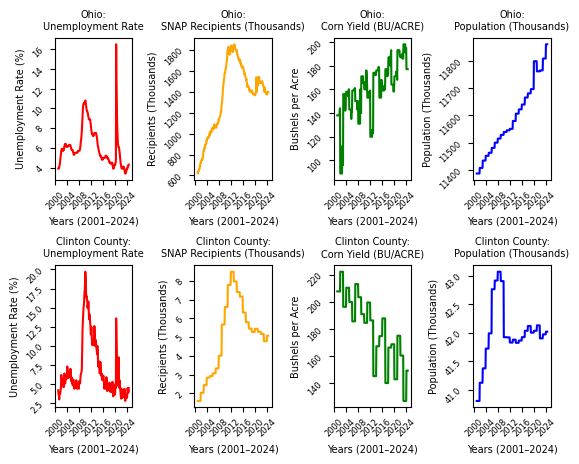

In [ ]:
# Univariate trend plots (time series 2001–2024)


#The Trends (Univariate Analysis)
fig1 = plt.figure()
ohio_unem = fig1.add_subplot(2, 4, 1)
ohio_snap = fig1.add_subplot(2, 4, 2)
ohio_corn = fig1.add_subplot(2, 4, 3)
ohio_popu = fig1.add_subplot(2, 4, 4)
clinton_unem = fig1.add_subplot(2, 4, 5)
clinton_snap = fig1.add_subplot(2, 4, 6)
clinton_corn = fig1.add_subplot(2, 4, 7)
clinton_popu = fig1.add_subplot(2, 4, 8)


# Clinton
clinton_unem.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Unemployment_Rate_Clinton"],
    color="red",
    alpha = 1
)
clinton_unem.set_title("Clinton County:\nUnemployment Rate", fontsize=7)
clinton_unem.set_ylabel("Unemployment Rate (%)", fontsize=7)
clinton_unem.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_unem.tick_params(labelsize=6, rotation=45)


clinton_snap.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton"]/1000,
    color="orange",
    alpha = 1
)
clinton_snap.set_title("Clinton County:\nSNAP Recipients (Thousands)", fontsize=7)
clinton_snap.set_ylabel("Recipients (Thousands)", fontsize=7)
clinton_snap.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_snap.tick_params(labelsize=6, rotation=45)


clinton_corn.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    color="green",
    alpha = 1
)
clinton_corn.set_title("Clinton County:\nCorn Yield (BU/ACRE)", fontsize=7)
clinton_corn.set_ylabel("Bushels per Acre", fontsize=7)
clinton_corn.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_corn.tick_params(labelsize=6, rotation=45)


clinton_popu.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Clinton_Population_In_Thousands"],
    color="blue"
)
clinton_popu.set_title("Clinton County:\nPopulation (Thousands)", fontsize=7)
clinton_popu.set_ylabel("Population (Thousands)", fontsize=7)
clinton_popu.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_popu.tick_params(labelsize=6, rotation=45)


# Ohio
ohio_unem.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Unemployment_Rate_Ohio"],
    color="red"
)
ohio_unem.set_title("Ohio:\nUnemployment Rate", fontsize=7)
ohio_unem.set_ylabel("Unemployment Rate (%)", fontsize=7)
ohio_unem.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_unem.tick_params(labelsize=6, rotation=45)


ohio_snap.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio"]/1000,
    color="orange"
)
ohio_snap.set_title("Ohio:\nSNAP Recipients (Thousands)", fontsize=7)
ohio_snap.set_ylabel("Recipients (Thousands)", fontsize=7)
ohio_snap.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_snap.tick_params(labelsize=6, rotation=45)


ohio_corn.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    color="green",
    alpha = 1
)
ohio_corn.set_title("Ohio:\nCorn Yield (BU/ACRE)", fontsize=7)
ohio_corn.set_ylabel("Bushels per Acre", fontsize=7)
ohio_corn.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_corn.tick_params(labelsize=6, rotation=45)


ohio_popu.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Ohio_Population_In_Thousands"],
    color="blue"
)
ohio_popu.set_title("Ohio:\nPopulation (Thousands)", fontsize=7)
ohio_popu.set_ylabel("Population (Thousands)", fontsize=7)
ohio_popu.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_popu.tick_params(labelsize=6, rotation=45)

# Layout spacing
fig1.subplots_adjust(wspace=0.8, hspace=0.6)

#Saving the plot
save_path = "/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/graphs_dowloads/time_series.png"

# Check if file already exists before saving
if not os.path.exists(save_path):
    fig1.savefig(
        save_path,
        dpi=600,
        bbox_inches="tight",
        format="png"
    )
    print("The time series graph saved successfully.")
else:
    print("File already exists. Not saved.")

## 5. Distribution Analysis, Box Plots

Box plots (whisker plots) summarise the distribution of each variable. All variables use a **6 month lag shift** before plotting, because economic effects such as job losses or changes in SNAP enrollment typically do not appear immediate there is a delay.

The shifted DataFrame `combined_ohio_clinton_shifted_df` is used consistently from this point forward in the analysis. Rows with `NaN` values introduced by the shift are dropped.

The graph saved successfully.


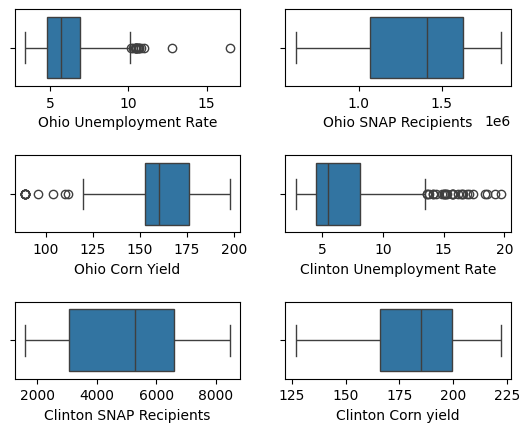

In [23]:
# Apply 6-month lag shift, then plot distributions box plots

# Since the effects are not seen immidiately create a leg of 6 months.
combined_ohio_clinton_df["Unemployment_Rate_Ohio_shifted"] = combined_ohio_clinton_df["Unemployment_Rate_Ohio"].shift(6)
combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio_shifted"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio"].shift(6)
combined_ohio_clinton_df["Unemployment_Rate_Clinton_shifted"] = combined_ohio_clinton_df["Unemployment_Rate_Clinton"].shift(6)
combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton_shifted"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton"].shift(6)
combined_ohio_clinton_df["Ohio_SNAP_Rate_shifted"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio"].shift(6)
combined_ohio_clinton_df["Clinton_SNAP_Rate"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton"].shift(6)
combined_ohio_clinton_shifted_df = combined_ohio_clinton_df.dropna()

# Create figure and subplots
fig2 = plt.figure()

# 1. Ohio Unemployment Rate
box_Unemployment_Rate_Ohio = fig2.add_subplot(3, 2, 1)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Unemployment_Rate_Ohio_shifted", 
    ax=box_Unemployment_Rate_Ohio
)
box_Unemployment_Rate_Ohio.set_xlabel("Ohio Unemployment Rate")


# 2. Ohio SNAP Recipients
box_Number_Of_Snap_Recipients_Ohio = fig2.add_subplot(3, 2, 2)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Number_Of_Snap_Recipients_Ohio_shifted", 
    ax=box_Number_Of_Snap_Recipients_Ohio
)
box_Number_Of_Snap_Recipients_Ohio.set_xlabel("Ohio SNAP Recipients")
# 3. Ohio Corn Yield
box_Ohio_Corn_Yield = fig2.add_subplot(3, 2, 3)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Ohio_Corn_Grain_Yield_BU/ACRE", 
    ax=box_Ohio_Corn_Yield
)
box_Ohio_Corn_Yield.set_xlabel("Ohio Corn Yield")
# 4. Clinton Unemployment Rate
box_Unemployment_Rate_Clinton = fig2.add_subplot(3, 2, 4)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Unemployment_Rate_Clinton_shifted", 
    ax=box_Unemployment_Rate_Clinton
)
box_Unemployment_Rate_Clinton.set_xlabel("Clinton Unemployment Rate")

# 5. Clinton SNAP Recipients
box_Number_Of_Snap_Recipients_Clinton = fig2.add_subplot(3, 2, 5)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Number_Of_Snap_Recipients_Clinton_shifted", 
    ax=box_Number_Of_Snap_Recipients_Clinton
)
box_Number_Of_Snap_Recipients_Clinton.set_xlabel("Clinton SNAP Recipients")

# 6. Clinton Corn Yield
box_Clinton_Corn_Yield = fig2.add_subplot(3, 2, 6)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Clinton_Corn_Grain_Yield_BU/ACRE", 
    ax=box_Clinton_Corn_Yield,
)
box_Clinton_Corn_Yield.set_xlabel("Clinton Corn yield")
fig2.subplots_adjust(hspace=0.9, wspace=0.2)

#Save the file
save_path = "/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/graphs_dowloads/box_plots.png"

# Check if file already exists before saving
if not os.path.exists(save_path):
    fig2.savefig(
        save_path,
        dpi=600,
        bbox_inches="tight",
        format="png"
    )
    print("The graph saved successfully.")
else:
    print("File already exists. Not saved.")

## 6. Correlation Matrix

The Pearson correlation matrix shows the pairwise linear relationships between all numeric variables in the combined dataset. Values range from **-1** (perfect negative correlation) to **+1** (perfect positive correlation), with **0** indicating no linear association.

In [18]:
#Pearson correlation matrix across all numeric variables

correlation_matrix = combined_ohio_clinton_df.select_dtypes(include="number").corr()
correlation_matrix

,Unemployment_Rate_Ohio,Number_Of_Snap_Recipients_Ohio,Ohio_Corn_Grain_Yield_BU/ACRE,Ohio_Population_In_Thousands,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE,Clinton_Population_In_Thousands,Ohio_SNAP_Rate,Clinton_SNAP_Rate,Unemployment_Rate_Ohio_shifted,Number_Of_Snap_Recipients_Ohio_shifted,Unemployment_Rate_Clinton_shifted,Number_Of_Snap_Recipients_Clinton_shifted,Ohio_SNAP_Rate_shifted
Unemployment_Rate_Ohio,1.000000,0.266846,-0.170131,-0.270385,0.897546,0.300988,0.202191,0.203032,0.286443,0.164570,0.702956,0.114596,0.693393,0.164570,0.114596
Number_Of_Snap_Recipients_Ohio,0.266846,1.000000,0.436178,0.546953,0.472845,0.978856,-0.544611,0.218975,0.999288,0.972316,0.377506,0.985806,0.564766,0.972316,0.985806
Ohio_Corn_Grain_Yield_BU/ACRE,-0.170131,0.436178,1.000000,0.725717,-0.089114,0.319566,-0.736190,0.246175,0.414442,0.345634,-0.130740,0.441618,-0.101201,0.345634,0.441618
Ohio_Population_In_Thousands,-0.270385,0.546953,0.725717,1.000000,-0.210420,0.453447,-0.830026,0.171089,0.515236,0.464570,-0.274643,0.555387,-0.215789,0.464570,0.555387
Unemployment_Rate_Clinton,0.897546,0.472845,-0.089114,-0.210420,1.000000,0.509250,0.116791,0.142567,0.494325,0.388253,0.786437,0.344396,0.872775,0.388253,0.344396
Number_Of_Snap_Recipients_Clinton,0.300988,0.978856,0.319566,0.453447,0.509250,1.000000,-0.483423,0.146561,0.981649,0.976017,0.384824,0.966556,0.586179,0.976017,0.966556
Clinton_Corn_Grain_Yield_BU/ACRE,0.202191,-0.544611,-0.736190,-0.830026,0.116791,-0.483423,1.000000,-0.058262,-0.520187,-0.522310,0.205761,-0.572729,0.111946,-0.522310,-0.572729
Clinton_Population_In_Thousands,0.203032,0.218975,0.246175,0.171089,0.142567,0.146561,-0.058262,1.000000,0.220269,0.021430,0.091232,0.090611,-0.017215,0.021430,0.090611
Ohio_SNAP_Rate,0.286443,0.999288,0.414442,0.515236,0.494325,0.981649,-0.520187,0.220269,1.000000,0.972689,0.399157,0.982611,0.587885,0.972689,0.982611
Clinton_SNAP_Rate,0.164570,0.972316,0.345634,0.464570,0.388253,0.976017,-0.522310,0.021430,0.972689,1.000000,0.304254,0.978973,0.512031,1.000000,0.978973


## Hypothesis Testing Corn Yield vs. Unemployment & SNAP

**Hypothesis:** There is a statistically significant relationship between corn grain yield and both unemployment rate and SNAP enrollment, in both Ohio and Clinton County.

To test this, Pearson correlation coefficients and their associated **p-values** are computed for four variable pairs:
1. Ohio corn yield vs. Ohio unemployment rate
2. Ohio corn yield vs. Ohio SNAP recipients
3. Clinton corn yield vs. Clinton unemployment rate
4. Clinton corn yield vs. Clinton SNAP recipients

A **p-value < 0.05** indicates the correlation is statistically significant at the 95% confidence level. The scatter plots below display each relationship with a linear regression trendline and the corresponding p-value annotated directly on the chart.

> **Note:** All comparisons use the 6-month lagged values established in Section 5, reflecting the delayed economic response to agricultural changes.

Unemployment rate  and corn yield ohio:
Regression = -0.13074044418362696 and p value = 0.02989380053299289

Snap benefitand Corn yield Ohio:
Regression = 0.44161750541370737 and p value =  1.328815e-14

Unemployment rate and corn yield Clinton:
Regression = 0.11194626306172491 and p value =  6.328382e-02

Snap benefit Ohio and corn yield Clinton:
Regression = -0.5223095831314963 and p value =  1.015372e-20

The graph saved successfully.


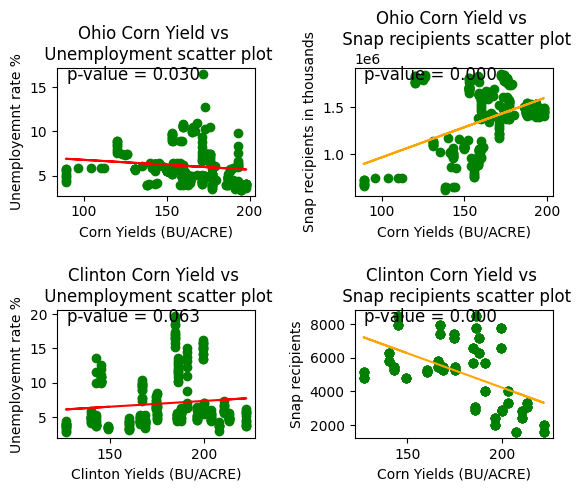

In [28]:
# Hypothesis testing, Pearson r and p-values, then scatter plots

#Ohio 
#First calculate the p value

#Unemployment and corn ohio
regession_oh_u, p_value_oh_u = stats.pearsonr(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Ohio_shifted"])
print("Unemployment rate  and corn yield ohio:")
print(f"Regression = {regession_oh_u} and p value = {p_value_oh_u}")
print()

#Snap Ohio and Corn
regession_oh_s, p_value_oh_s = stats.pearsonr(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Ohio_shifted"])
print("Snap benefitand Corn yield Ohio:")
print(f"Regression = {regession_oh_s} and p value = {p_value_oh_s: 2e}")
print()

#Unemployment and corn Clinton
regession_clint_u, p_value_clint_u = stats.pearsonr(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Clinton_shifted"],
)
print("Unemployment rate and corn yield Clinton:")
print(f"Regression = {regession_clint_u} and p value = {p_value_clint_u: 2e}")
print()

#Snap Ohio and  and corn yield Clinton
regession_clint_s, p_value_clint_s = stats.pearsonr(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Clinton_shifted"])
print("Snap benefit Ohio and corn yield Clinton:")
print(f"Regression = {regession_clint_s} and p value = {p_value_clint_s: 2e}")
print()


#Plots showing corelation significance and p_values
fig3 = plt.figure()
corn_unump_ohio = fig3.add_subplot(2, 2, 1)
corn_unump_ohio.scatter(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Ohio_shifted"],
    color = "green"
    );

m1, c1 = np.polyfit(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Ohio_shifted"],
    deg= 1,
)
corn_unump_ohio.plot(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"] * m1 + c1,
    color = "red",
);

corn_unump_ohio.text(
    0.05, 0.95,      
    f"p-value = {p_value_oh_u:.3f}", 
    transform=corn_unump_ohio.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_unump_ohio.set_title("Ohio Corn Yield vs \n Unemployment scatter plot")
corn_unump_ohio.set_ylabel("Unemployemnt rate %")
corn_unump_ohio.set_xlabel("Corn Yields (BU/ACRE)")

#Corn Ohio and Snap 
corn_snap_oh = fig3.add_subplot(2, 2, 2)
corn_snap_oh.scatter(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Ohio_shifted"],
    color = "green"
);
m2, c2 = np.polyfit(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Ohio_shifted"],
    deg = 1
)

corn_snap_oh.plot(
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Ohio_Corn_Grain_Yield_BU/ACRE"]*m2 + c2,
    color = "orange"
    );
corn_snap_oh.text(
    0.05, 0.95,      
    f"p-value = {p_value_oh_s:.3f}", 
    transform=corn_snap_oh.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_snap_oh.set_title("Ohio Corn Yield vs \n Snap recipients scatter plot")
corn_snap_oh.set_ylabel("Snap recipients in thousands")
corn_snap_oh.set_xlabel("Corn Yields (BU/ACRE)")

#Clinton unemployment vs Corn
corn_unump_clinton = fig3.add_subplot(2, 2, 3)
corn_unump_clinton.scatter(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Clinton_shifted"],
    color = "green"
)

m3, c3 = np.polyfit(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Unemployment_Rate_Clinton_shifted"],
    deg = 1
)
corn_unump_clinton.plot(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"] * m3 + c3,
    color = "red"

)
corn_unump_clinton.text(
    0.05, 0.95,      
    f"p-value = {p_value_clint_u:.3f}", 
    transform=corn_unump_clinton.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_unump_clinton.set_title("Clinton Corn Yield vs \n Unemployment scatter plot")
corn_unump_clinton.set_ylabel("Unemployemnt rate %")
corn_unump_clinton.set_xlabel("Clinton Yields (BU/ACRE)");

#Clinton Snap and corn
corn_snap_clinton = fig3.add_subplot(2, 2, 4)
corn_snap_clinton.scatter(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Clinton_shifted"],
    color = "green"
)

m4, c4 = np.polyfit(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Number_Of_Snap_Recipients_Clinton_shifted"],
    deg = 1
)
corn_snap_clinton.plot(
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    combined_ohio_clinton_shifted_df["Clinton_Corn_Grain_Yield_BU/ACRE"] * m4 + c4,
    color = "orange"
)
corn_snap_clinton.text(
    0.05, 0.95,      
    f"p-value = {p_value_clint_s:.3f}", 
    transform=corn_snap_clinton.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_snap_clinton.set_title("Clinton Corn Yield vs \n Snap recipients scatter plot")
corn_snap_clinton.set_ylabel("Snap recipients")
corn_snap_clinton.set_xlabel("Corn Yields (BU/ACRE)");

#Adjust my figure
fig3.subplots_adjust(wspace=0.5, hspace=0.9)
save_path = "/workspaces/INTRODUCTION-TO-DATA-SCIENCE-AND-DATA-VIZUALIZATION/project_final/graphs_dowloads/correlation_graph.png"

# Check if file already exists before saving
if not os.path.exists(save_path):
    fig3.savefig(
        save_path,
        dpi=600,
        bbox_inches="tight",
        format="png"
    )
    print("The graph saved successfully.")
else:
    print("File already exists. Not saved.")